In [1]:
import os
import sys
import tkinter
import abtem

cwd0 = '../styles/'
sys.path.append(cwd0)

import visualID as vID
from visualID import  fg, hl, bg

import gzip
import numpy as np

cwd1= '../'
sys.path.append(cwd1)


from pyNanoMatBuilder import TEM_creator as tc
from pyNanoMatBuilder import utils as pyNMBu
from pyNanoMatBuilder import data

import matplotlib.pyplot as plt
import numpy as np
import importlib
import ase 
from ase.io import read

## abTEM guide

### Using abTEM to Generate HRTEM Images: Parameter Guide

High-resolution transmission electron microscopy (HRTEM) is a powerful experimental technique for studying materials at the atomic scale. In HRTEM, the exit wave—the electron wavefunction after passing through the sample—contains maximum structural information. However, lens aberrations and detection processes cause information loss and blurring in the final image.

This notebook demonstrates how to use **abTEM** to simulate HRTEM images with physically realistic parameters. The goal is to create a machine learning database for predicting atomic structures from experimental HRTEM data. Below, we explain the key simulation parameters and their physical significance.


A similar work has already been done (but only on a few compounds): **"Simulated HRTEM images of nanoparticles to train a neural network for crystallinity classification"** (https://www.sciencedirect.com/science/article/pii/S0304399122001607). They also used **abTEM** (https://abtem.readthedocs.io/en/latest/intro.html) to generate their ML database, I will use pretty much the same parameters of microscope as a starting point.

In [ ]:
abtem.config.set({"device": "cpu", "fft": "fftw"})

## Main microscope parameters

Choose the thickness of the carbon grid. If the grid is too thick, it is hard to see the NP. 

##### NP on a 5x5x2 nm carbon grid

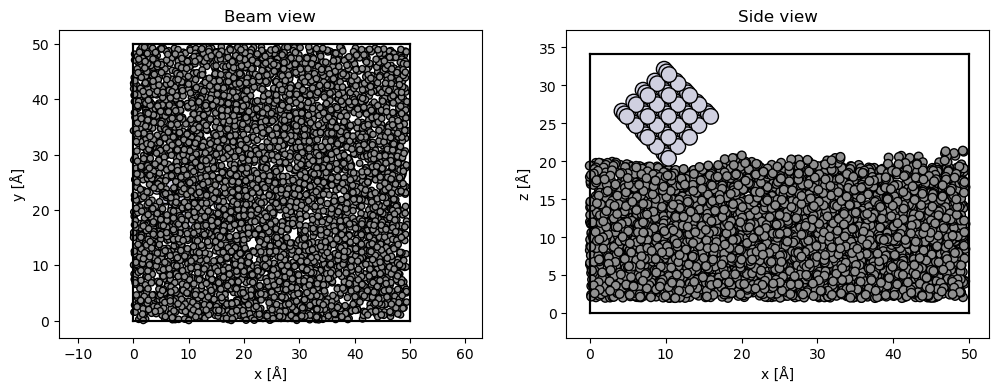

In [ ]:
atoms = read('HRTEM_xyz/Pt_fcc_cube_000125.xyz') # put the file here 

# only keeping 20 Angstrom of width for the carbon substrate (questionning how much we should leave ?)
z_min = 30
z_max = 100

atoms = atoms[[z_min <= atom.position[2] <= z_max for atom in atoms]]

atoms.set_cell([50, 50, 50]) # put the initial size of the substrare (here 50x50x50 Angstrom)
atoms.center(axis=2, vacuum=2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
abtem.show_atoms(atoms, plane="xy", ax=ax1, title="Beam view")
abtem.show_atoms(atoms, plane="xz", ax=ax2, title="Side view");


##### Thicker grid: NP on a 5x5x3 nm carbon grid

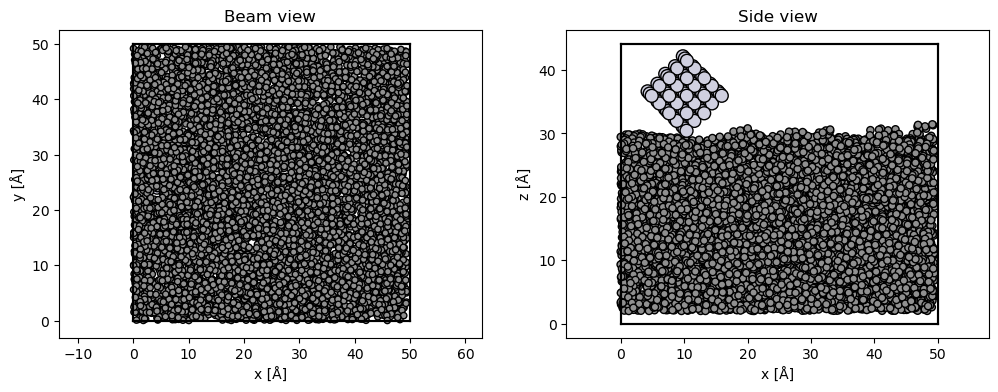

In [ ]:
atoms = read('HRTEM_xyz/Pt_fcc_cube_000125.xyz') # put the file here 

z_min = 20
z_max = 100

atoms = atoms[[z_min <= atom.position[2] <= z_max for atom in atoms]]

atoms.set_cell([50, 50, 50])
atoms.center(axis=2, vacuum=2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
abtem.show_atoms(atoms, plane="xy", ax=ax1, title="Beam view")
abtem.show_atoms(atoms, plane="xz", ax=ax2, title="Side view");

#### Potential
##### Frozen phonons
Thermical atomic vibrations (phonons) lead to many configurations around an equilibrium position. They're called "frozen phonons" because each configuration represents a frozen moment corresponding to a specific thermic vibration at a specific temperature.  They need to be taken in account in the model because they impact the final image (scattered noise, kikuchi lines, etc). 
\


The function **`abtem.FrozenPhonons(atoms, num_configs, sigmas)`** is used to generate this ensemble:

- **`atoms`**: atomic structure (ASE `Atoms` object).  
- **`num_configs`**: number of frozen configurations to sample.  
- **`sigmas`**: standard deviation of atomic displacements (in Å), which sets vibration amplitude.

In practice, `sigmas` increases with temperature and also depends on the material (bond strength, atomic mass, etc.). A rigorous choice would come from a physical model (e.g., Debye–Waller-related estimate), but as a first approximation, values around **0.1–0.2 Å** are commonly used.

In [ ]:
frozen_phonons = abtem.FrozenPhonons(atoms, 4, sigmas=0.2)

##### Sampling and slice thickness



The function **`abtem.Potential(frozen_phonons, sampling, projection, slice_thickness)`** constructs the electrostatic potential through which the electron beam propagates:

- **`frozen_phonons`**: the ensemble of atomic configurations including thermal vibrations.
- **`sampling`**: spatial resolution in Å/pixel. Smaller values (e.g., 0.05 Å) give higher resolution but increase computation time.
- **`projection`**: method for projecting the 3D potential. `"infinite"` assumes an infinite projection along the beam direction. (verify this part)
- **`slice_thickness`**: thickness of each slice (in Å) used in the multislice algorithm. The specimen is divided into thin slices to accurately model electron-specimen interaction. Thinner slices improve accuracy but require more computation.

In [ ]:
potential = abtem.Potential(
    frozen_phonons,
    sampling=0.05,
    projection="infinite",
    slice_thickness=1,
)

#### Wave function

The maximal amount of information about the sample is present in the exit wave, i.e. the wavefunction of the electrons exiting the sample. As the image is formed, some of this information is blurred or lost, both due to aberration in the lenses, and because the camera detects the intensity of the wave, not its phase.

Here, we create a plane wave function at an energy of 200 keV. 

In [ ]:
wave = abtem.PlaneWave(energy=200e3)

#### Multislice

The expensive part of the image simulation is the multislice algorithm (cf slice_thickness).

In [ ]:
exit_wave = wave.multislice(potential)
exit_wave.compute()

[########################################] | 100% Completed | 10.59 s


**Nb : reducing the thickness of the carbon grid decreases the computational time (t/2)**

## Image formation: CTF, MTF, and noise

#### Contrast transfer function (CTF) and Modulation Transfer Function (MTF)
- CTF modelizes how the contrast is transferred from one object to the image. It depends on spherical aberration, defocus (distance from the ideal focus), astigmatism (difference of focalisation) and semi angle cutoff (angle limit of the objective).
- MTF modelizes the response from the detector, it describes how the spatial frequencies are attenuated because of the detector's resolution. It's an intersting function to simulate instrumental contributions. The article **"A Deep Learning Approach to Identify Local Structures in Atomic-Resolution Transmission Electron Microscopy Images"** (cf https://advanced.onlinelibrary.wiley.com/doi/10.1002/adts.201800037) explains why it is important (2.3): MTF makes the CNN avoid learning irrealistic artefacts, the latter is essential as it has a strong influence on the spectral properties of the noise, and prevents that the network is trained incorrectly to detect atoms by the absence of pure white noise.




The action of the CTF and the MTF are computationally cheap, and for that reason it is convenient to generate multiple images of the same sample with varying microscope parameters.


#### CTF

defocus = -54.86 Å


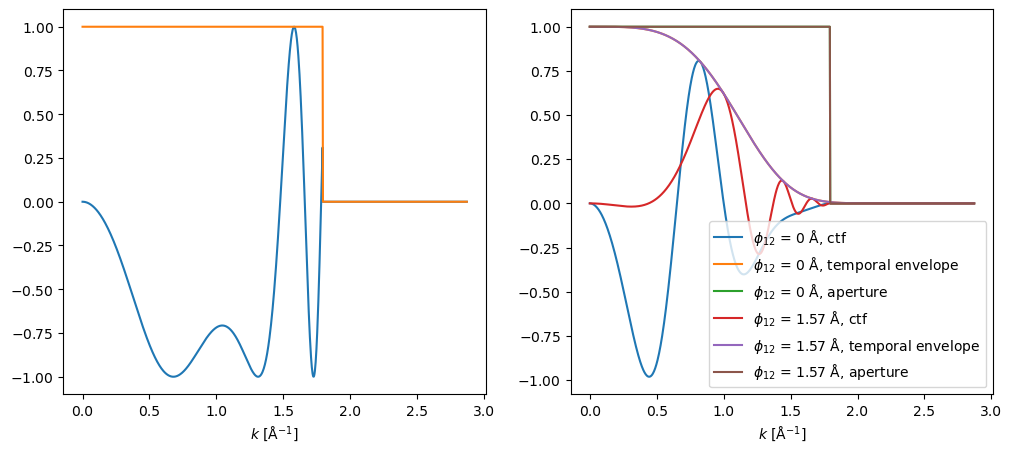

In [ ]:
################# CTF ###############################

Cs = -8e-6 * 1e10  # spherical aberration (-8 um)
ctf = abtem.CTF(Cs=Cs, energy=wave.energy, defocus="scherzer", semiangle_cutoff=45)
print(f"defocus = {ctf.defocus:.2f} Å")


################## astigmatism #################################

ctf_asymmetric = ctf.copy()
ctf_asymmetric.astigmatism = 50
#ctf_asymmetric.astigmatism_x = 500  # Strength of astigmatism in the x direction
ctf_asymmetric.astigmatism_y = 0  # Strength of astigmatism in the y direction
ctf_asymmetric.astigmatism_angle = np.array([0, np.pi / 2])  # 0 for x, pi/2 for y


########### partial coherence in the quasi-coherent approximation ####################

Cc = 1.0e-3 * 1e10  # chromatic aberration (1.2 mm)
energy_spread = 0.35  # standard deviation energy spread (0.35 eV)
focal_spread = Cc * energy_spread / exit_wave.energy
#incoherent_ctf = ctf.copy()
incoherent_ctf = ctf_asymmetric.copy()
incoherent_ctf.focal_spread = focal_spread


################# show ##########################################
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ctf.profiles().show(ax=ax1)
incoherent_ctf.profiles().show(ax=ax2, legend=True);

In [ ]:
########################### Apply CTF #################################
measurement_ensemble = exit_wave.apply_ctf(incoherent_ctf).intensity()
measurement_ensemble.shape

(2, 4, 1000, 1000)

#### First image

The result is an ensemble of images, one for each frozen phonon, we average the ensemble to obtain the final image.

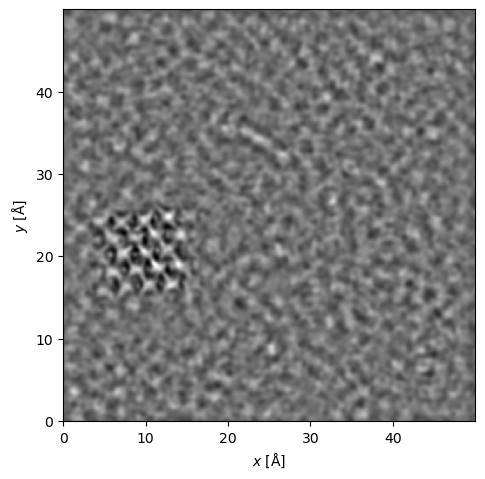

In [ ]:
measurement = measurement_ensemble.mean(0)
measurement.show(cmap='gray');

Save the image

In [ ]:
# Convert noisy_measurement to a NumPy array
image_data = measurement.array
print(image_data.shape)
mean_data = np.mean(image_data, axis=0)
print(mean_data.shape)
# Plot and save the image
plt.imshow(mean_data, cmap='gray')
plt.axis('off')  # Remove axes for a clean image
plt.savefig("measurement.png", dpi=300, bbox_inches='tight')

plt.close()

(4, 1000, 1000)
(1000, 1000)


#### Post processing the image

First, adding poisson noise:

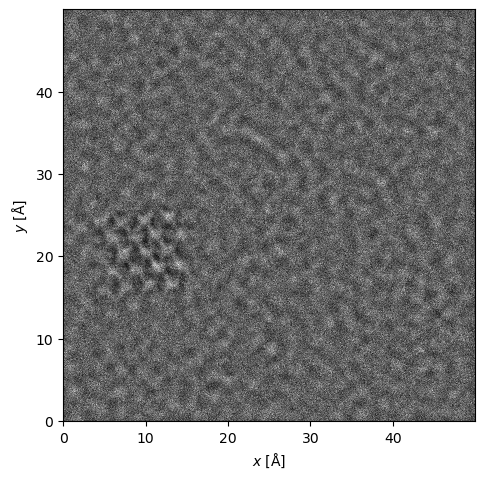

In [ ]:
noisy_measurement = measurement.poisson_noise(dose_per_area=1e4)
noisy_measurement.show(cmap='gray')

In [ ]:
# Convert noisy_measurement to a NumPy array
image_data = noisy_measurement.array
print(image_data.shape)
mean_data = np.mean(image_data, axis=0)
print(mean_data.shape)
# Plot and save the image
plt.imshow(mean_data, cmap='gray')
plt.axis('off')  # Remove axes for a clean image
plt.savefig("./noisy_measurement.png", dpi=300, bbox_inches='tight')

plt.close()

(4, 1000, 1000)
(1000, 1000)


#### MTF

The Modulation Transfer Function (MTF) is a measure of how well the contrast in an object is transferred to an image by a detector. It characterizes the fidelity of the spatial frequency content of the object in the resulting image. The MTF is determined by the ratio of modulations between the image and the object, and it varies with spatial frequency. (https://www.sciencedirect.com/topics/physics-and-astronomy/modulation-transfer-function). 
Formula given by https://advanced.onlinelibrary.wiley.com/doi/10.1002/adts.201800037, part 2.3.

In [ ]:
print(mean_data.shape)

(1000, 1000)


Own function (with help of chatpgt, not sure I've understood everything :S)

In [ ]:
def mtf_function(q, q_N, c1, c2, c3):
    return (1 - c1) / (1 + (q / (2 * c2 * q_N))**c3) + c1 # formula in the article

from numpy.fft import fft2, ifft2, fftshift, ifftshift

# parameters
pixel_size = 0.05  # cmb de angs sont couverts par un pixel
q_N = 1 / (2 * pixel_size)
print('q_N',q_N)
c1, c2, c3 = 0.1, 0.25, 2  # (see table)

# Compute the spatial frequencies q
ny, nx = mean_data.shape
qx = np.fft.fftfreq(nx, d=pixel_size)
qy = np.fft.fftfreq(ny, d=pixel_size)
qx, qy = np.meshgrid(qx, qy)
q = np.sqrt(qx**2 + qy**2)

# Compute the MTF
mtf = mtf_function(q, q_N, c1, c2, c3)

# Apply MTF
image_fft = fft2(mean_data) # fourier transform of the image: image in the frequency space (where low and high frequencies are separated)
image_fft_filtered = image_fft * fftshift(mtf) # each spatial frequency is multiplied by its MFT value
image_filtered = np.real(ifft2(image_fft_filtered)) # back to the real space of the iamge 

q_N 10.0


Function from someone's github (https://github.com/u-onder/mtf.py) NOT WORKING :(

In [ ]:
# import mtf as mtf
# imgArr = mtf.Helper.LoadImageAsArray('images/noisy_measurement.png')
# res = mtf.MTF.CalculateMtf(imgArr, verbose=mtf.Verbosity.DETAIL)

New image with MFT: 

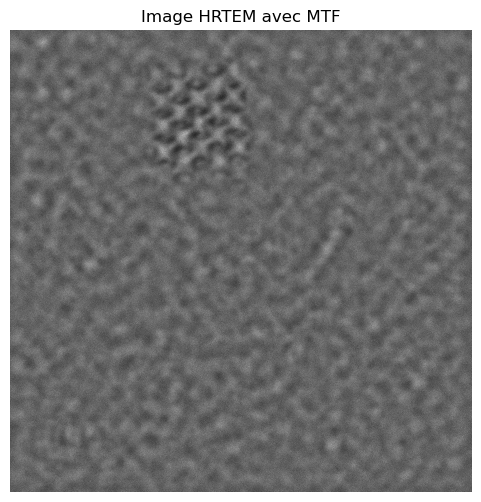

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(image_filtered, cmap='gray')
plt.title('Image HRTEM avec MTF')
plt.axis('off')
plt.show()
plt.imsave("hrtem_mtf.png", image_filtered, cmap='gray')



#### Let's compare different values of c1, c2, c3 

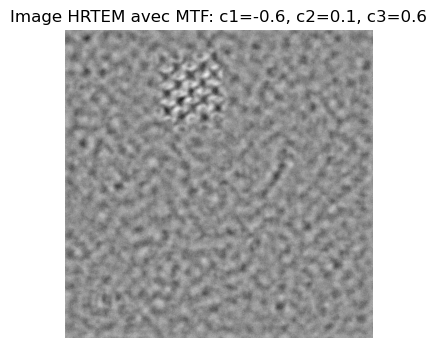

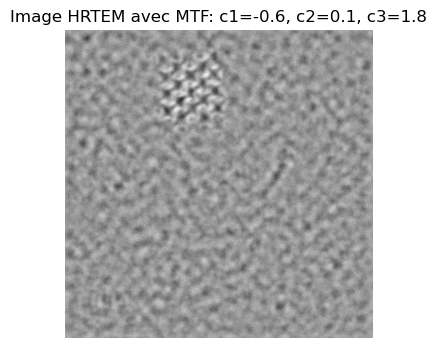

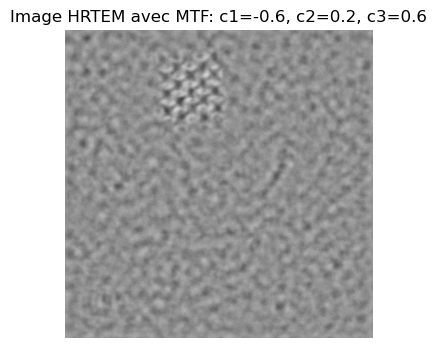

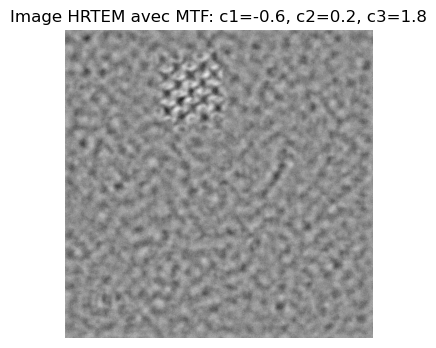

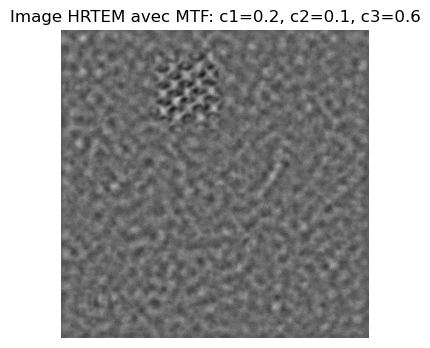

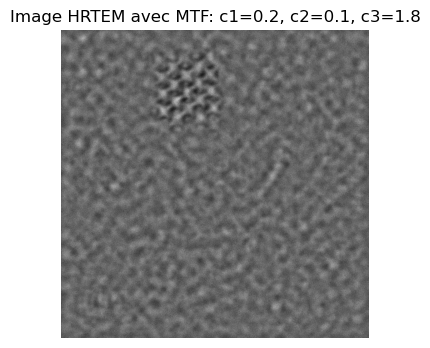

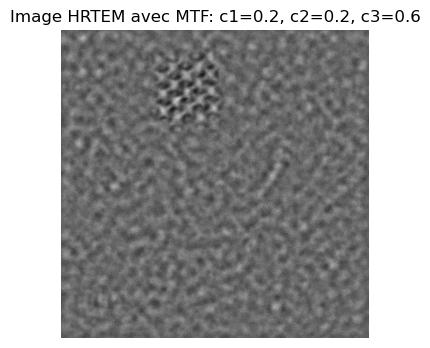

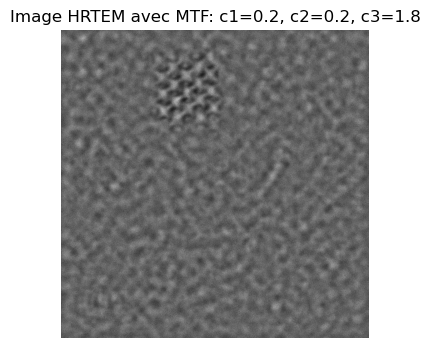

In [ ]:
for c1 in [-0.6,0.2]:
    for c2 in [0.1,0.2]:
        for c3 in [0.6, 1.8]:
            mtf = mtf_function(q, q_N, c1=c1, c2=c2, c3=c3)
            image_fft = fft2(mean_data) # fourier transform of the image: image in the frequency space (where low and high frequencies are separated)
            image_fft_filtered = image_fft * fftshift(mtf) # each spatial frequency is multiplied by its MFT value
            image_filtered = np.real(ifft2(image_fft_filtered)) # back to the real space of the iamge 


            
            plt.figure(figsize=(4,4))
            plt.imshow(image_filtered, cmap='gray')
            plt.title(f'Image HRTEM avec MTF: c1={c1}, c2={c2}, c3={c3}')
            plt.axis('off')
            plt.show()        

In [1]:
### should continue to study the parameters (astigmatism for example)